In [1]:
# import required packages

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.multioutput import MultiOutputRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print('imported successfully...')

imported successfully...


In [53]:
# load data
df = pd.read_csv('patient_recovery_data.csv')
df

# property to be predicted
# 1. Recovery_Days
# 2. Pain_Reduction_Score

,Age,BMI,Blood_Pressure,Therapy_Hours,Medication_Dosage,Preexisting_Score,Recovery_Days,Pain_Reduction_Score
0,58,35.5,129.0,14.3,76.3,0,67.2,0.0
1,71,19.2,71.0,16.1,76.7,4,44.7,7.7
2,48,39.7,70.0,17.9,14.8,9,77.4,0.0
3,34,34.9,117.0,7.4,90.7,8,98.7,0.0
4,62,22.0,81.0,8.1,53.0,5,64.6,0.0
...,...,...,...,...,...,...,...,...
115,79,38.3,105.0,15.8,87.3,9,103.4,0.0
116,79,37.2,114.0,7.5,9.3,1,96.8,0.0
117,64,23.3,89.0,18.7,7.5,0,36.0,11.9
118,60,32.3,134.0,17.3,40.8,9,83.4,0.0


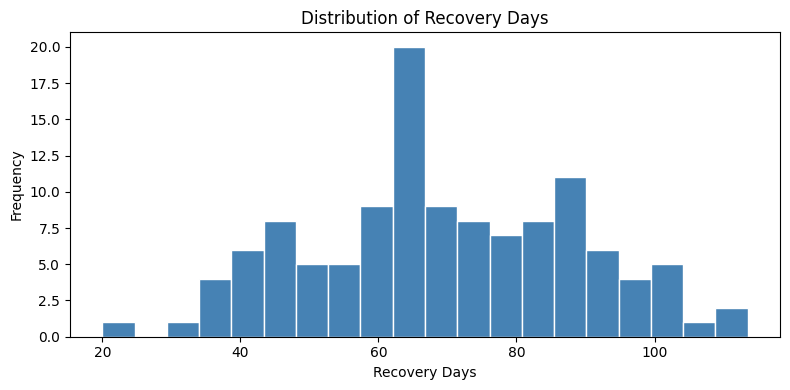

In [54]:
# explore data
plt.figure(figsize=(8, 4))
plt.hist(df['Recovery_Days'], bins=20, color='steelblue', edgecolor='white')
plt.title('Distribution of Recovery Days')
plt.xlabel('Recovery Days')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

In [55]:
# check for null values
print(df.info())
print('\n')
print(df.isnull().sum())
print('\n')
print(df.isna().sum())

<class 'pandas.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Age                   120 non-null    int64  
 1   BMI                   120 non-null    float64
 2   Blood_Pressure        115 non-null    float64
 3   Therapy_Hours         120 non-null    float64
 4   Medication_Dosage     115 non-null    float64
 5   Preexisting_Score     120 non-null    int64  
 6   Recovery_Days         120 non-null    float64
 7   Pain_Reduction_Score  120 non-null    float64
dtypes: float64(6), int64(2)
memory usage: 7.6 KB
None


Age                     0
BMI                     0
Blood_Pressure          5
Therapy_Hours           0
Medication_Dosage       5
Preexisting_Score       0
Recovery_Days           0
Pain_Reduction_Score    0
dtype: int64


Age                     0
BMI                     0
Blood_Pressure          5
Therapy_Hours           0
Medication_Do

In [ ]:
# fill null values
# df.fillna(df.mean(), inplace=True)

#verify the null values
# print('--------verify the null values-----')
# print(df.isnull().sum())

--------verify the null values-----
Age                     0
BMI                     0
Blood_Pressure          0
Therapy_Hours           0
Medication_Dosage       0
Preexisting_Score       0
Recovery_Days           0
Pain_Reduction_Score    0
dtype: int64


In [56]:
features = ['Age','BMI','Blood_Pressure','Therapy_Hours','Medication_Dosage','Preexisting_Score']
output = ['Recovery_Days','Pain_Reduction_Score']
x = df[features]
y = df[output]

print('-----------features-----------')
print(x.head())
print('\n-----------output-----------')
print(y.head())

-----------features-----------
   Age   BMI  Blood_Pressure  Therapy_Hours  Medication_Dosage  \
0   58  35.5           129.0           14.3               76.3   
1   71  19.2            71.0           16.1               76.7   
2   48  39.7            70.0           17.9               14.8   
3   34  34.9           117.0            7.4               90.7   
4   62  22.0            81.0            8.1               53.0   

   Preexisting_Score  
0                  0  
1                  4  
2                  9  
3                  8  
4                  5  

-----------output-----------
   Recovery_Days  Pain_Reduction_Score
0           67.2                   0.0
1           44.7                   7.7
2           77.4                   0.0
3           98.7                   0.0
4           64.6                   0.0


In [57]:
# split the data set into test and train data
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=60)
y_test.head()

,Recovery_Days,Pain_Reduction_Score
21,83.4,0.0
105,44.7,10.2
97,63.8,0.0
93,76.9,0.0
3,98.7,0.0


In [62]:
x_train.fillna(x_train.mean(), inplace=True)

x_train.isna().sum()

x_test.fillna(x_test.mean(), inplace=True)
x_test.isna().sum()

Age                  0
BMI                  0
Blood_Pressure       0
Therapy_Hours        0
Medication_Dosage    0
Preexisting_Score    0
dtype: int64

In [60]:
# train the data

base_model = LinearRegression()
model = MultiOutputRegressor(base_model)
model.fit(x_train, y_train)

,estimator estimator: estimator objectAn estimator object implementing :term:`fit` and :term:`predict`.,LinearRegression()
,"n_jobs n_jobs: int or None, optional (default=None)The number of jobs to run in parallel.:meth:`fit`, :meth:`predict` and :meth:`partial_fit` (if supportedby the passed estimator) will be parallelized for each target.When individual estimators are fast to train or predict,using ``n_jobs > 1`` can result in slower performance dueto the parallelism overhead.``None`` means `1` unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all available processes / threads.See :term:`Glossary ` for more details... versionchanged:: 0.20 `n_jobs` default changed from `1` to `None`.",None
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [66]:
model.fit(x_test, y_test)

,estimator estimator: estimator objectAn estimator object implementing :term:`fit` and :term:`predict`.,LinearRegression()
,"n_jobs n_jobs: int or None, optional (default=None)The number of jobs to run in parallel.:meth:`fit`, :meth:`predict` and :meth:`partial_fit` (if supportedby the passed estimator) will be parallelized for each target.When individual estimators are fast to train or predict,using ``n_jobs > 1`` can result in slower performance dueto the parallelism overhead.``None`` means `1` unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all available processes / threads.See :term:`Glossary ` for more details... versionchanged:: 0.20 `n_jobs` default changed from `1` to `None`.",None
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [67]:
y_pred = model.predict(x_test)
y_pred

array([[ 8.32109122e+01,  1.06325323e+00],
       [ 4.95030237e+01,  6.71921144e+00],
       [ 7.33524187e+01, -1.04659179e+00],
       [ 8.04240426e+01, -2.41064552e+00],
       [ 8.96152434e+01, -1.29099652e+00],
       [ 6.65507026e+01,  1.94092520e+00],
       [ 3.71733298e+01,  8.73217958e+00],
       [ 8.37282831e+01, -1.41131935e+00],
       [ 4.53883149e+01,  6.32314269e+00],
       [ 6.30495935e+01,  2.53363665e+00],
       [ 6.64783502e+01, -1.19167729e+00],
       [ 8.65006015e+01, -9.21139599e-02],
       [ 6.37649027e+01,  3.14932080e+00],
       [ 4.40545510e+01,  1.14873277e+01],
       [ 6.51534812e+01,  1.90161765e+00],
       [ 6.82038132e+01,  1.80379185e+00],
       [ 3.57646376e+01,  7.80101607e+00],
       [ 6.26920620e+01,  5.13510628e+00],
       [ 3.88337496e+01,  8.49803934e+00],
       [ 7.13565538e+01,  2.67010230e+00],
       [ 6.77669777e+01,  1.25343963e+00],
       [ 9.66901050e+01, -1.39737162e+00],
       [ 9.46024698e+01, -1.26630641e+00],
       [ 5.

In [68]:
mae = mean_absolute_error(y_test,y_pred)
print(mae)

rmse = np.sqrt( mean_squared_error(y_test, y_pred) )
print(rmse)

r2 = r2_score(y_test, y_pred)
print(r2)

2.7019775291418955
3.543914354259279
0.8599722302067581


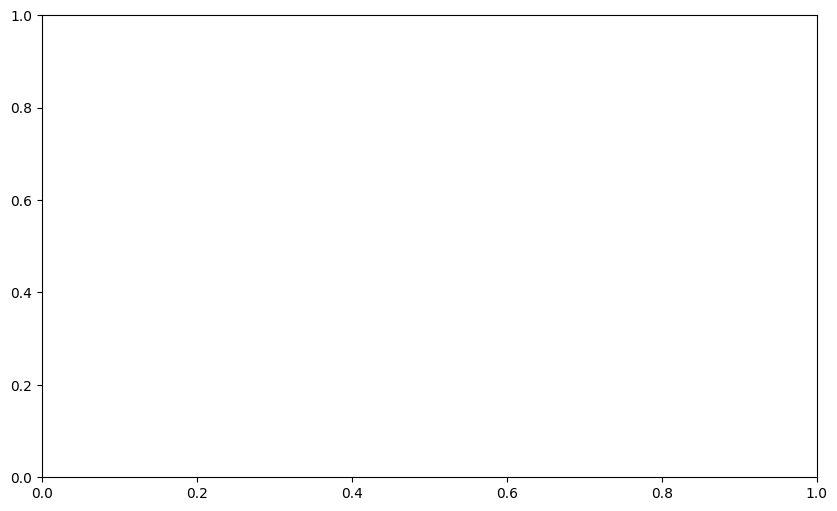

In [69]:
# plot the actual vs predicted values
fig, ax = plt.subplots(figsize=(10, 6))

In [70]:
new_patients = pd.DataFrame({
    'Age'               : [45,  72 ],
    'BMI'               : [24.5, 31.2],
    'Blood_Pressure'    : [120, 145 ],
    'Therapy_Hours'     : [12,   5  ],
    'Medication_Dosage' : [50,  80  ],
    'Preexisting_Score' : [2,    7  ]
})

# Fill any missing (none here, but good practice) then scale
new_patients_filled = new_patients.fillna(new_patients.mean())

preds = model.predict(new_patients_filled)

new_patients['Predicted_Recovery_Days']      = preds[:, 0].round(1)
new_patients['Predicted_Pain_Reduction']     = preds[:, 1].round(1)

print('🏥 Predicted Patient Outcomes:')
print(new_patients.to_string(index=False))


🏥 Predicted Patient Outcomes:
 Age  BMI  Blood_Pressure  Therapy_Hours  Medication_Dosage  Preexisting_Score  Predicted_Recovery_Days  Predicted_Pain_Reduction
  45 24.5             120             12                 50                  2                     50.8                       5.6
  72 31.2             145              5                 80                  7                    107.5                      -3.8
